In [33]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch import manual_seed
from torch._C._functionalization import split_with_sizes_ViewMeta
%matplotlib inline

In [34]:
words  = open('names.txt', 'r').read().split()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [35]:
chars = sorted(list(set(''.join(words))))
stoi  = {s : i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)

In [55]:
block_size = 8
def build_dataset(words):
    X , Y = [] , []

    for w in words:
        #print(w)
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            #print('.'.join(itos[i] for i in context), '------->' , itos[ix])
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr , Ytr = build_dataset(words[:n1])
Xdev ,Ydev = build_dataset(words[n1:n2] )
Xte , Yte = build_dataset(words[n2:])

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [56]:
for x , y in zip(Xtr[:20] , Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '----->' , itos[y.item()])

........ -----> e
.......e -----> b
......eb -----> r
.....ebr -----> i
....ebri -----> m
...ebrim -----> a
..ebrima -----> .
........ -----> h
.......h -----> i
......hi -----> l
.....hil -----> t
....hilt -----> o
...hilto -----> n
..hilton -----> .
........ -----> j
.......j -----> h
......jh -----> e
.....jhe -----> n
....jhen -----> e
...jhene -----> .


In [78]:
class Linear:

    def __init__(self, fan_in , fan_out , bias = True):
        self.weight = torch.randn((fan_in , fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    def __init__(self, dim , eps = 1e-5 , momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self ,x):
        if self.training:
            if x.ndim == 2:
                dim = 0
            if x.ndim == 3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)

        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean)/ torch.sqrt(xvar + self.eps)
        self.out = self.gamma*xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out

    def parameters(self):
        return [self.gamma  ,self.beta]


class Tanh:
    def __call__(self , x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return[]

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self , IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class FlattenConsecutive:

    def __init__(self,n):
        self.n = n

    def __call__(self, x):
        B ,T ,C = x.shape
        x = x.view(B , T//self.n , C*self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

        self.out = x.view(x.shape[0] , -1)
        return self.out

    def parameters(self):
        return []

class Sequential:

    def __init__(self, layers):
        self.layers = layers

    def __call__(self , x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [79]:
torch.manual_seed(42)

In [87]:
n_embd = 24
n_hidden = 128
g = torch.Generator().manual_seed(2147483647)

model = Sequential([
    Embedding(vocab_size , n_embd),
    FlattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    FlattenConsecutive(2),Linear(n_hidden* 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

76579


In [88]:
ix = torch.randint(0 , Xtr.shape[0] , (4,))
Xb , Yb = Xtr[ix] , Ytr[ix]
logits = model(Xb)
print(Xb.shape)
Xb

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0,  0,  0, 13, 25],
        [ 0,  0,  3,  8,  1, 14,  3,  5],
        [ 0,  0,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 12]])

In [89]:
for layer in model.layers:
    print(layer.__class__.__name__, ':' , tuple(layer.out.shape))

Embedding : (4, 8, 24)
FlattenConsecutive : (4, 4, 48)
Linear : (4, 4, 128)
BatchNorm1d : (4, 4, 128)
Tanh : (4, 4, 128)
FlattenConsecutive : (4, 2, 256)
Linear : (4, 2, 128)
BatchNorm1d : (4, 2, 128)
Tanh : (4, 2, 128)
FlattenConsecutive : (4, 256)
Linear : (4, 128)
BatchNorm1d : (4, 128)
Tanh : (4, 128)
Linear : (4, 27)


In [90]:
max_steps = 200000
batch_size = 32
lossi = []


for i in range(max_steps):

    ix = torch.randint(0 , Xtr.shape[0] , (batch_size,) , generator=g)
    Xb, Yb  = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)


    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1 if i < 150000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i % 100000 == 0:
        print(f'{i:7d}/{max_steps:7d} : {loss.item():7.4f}')
    lossi.append(loss.log10().item())


      0/ 200000 :  3.6580
 100000/ 200000 :  2.2546


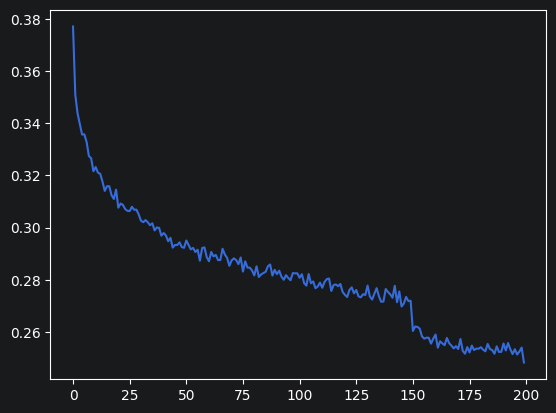

In [91]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [92]:
for layer in model.layers:
    layer.training = False

In [93]:
@torch.no_grad()
def split_loss(split):
    x , y = {
        'train':(Xtr , Ytr),
        'val' : (Xdev , Ydev),
        'test' : (Xte , Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits , y)
    print(split , loss.item())

split_loss('train')
split_loss('val')

train 1.7628839015960693
val 1.9928659200668335


In [53]:
for _ in range(20):

    out =[]
    context = [0]*block_size

    while True:

        logits = model(torch.tensor([context]))
        probs = F.softmax(logits , dim = 1)

        ix = torch.multinomial(probs, num_samples = 1).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

kqlmtoaeomhxhmfoxncwltirwevuxrgrg.
hwyhpe.
nnbhopruovcjkmurnxuuzmoibrezwnvkxymawaubmln.
fstrqln.
jwnrfvglyngo.
uw.
xqazndwkhpoafh.
crvzczmsbdvjyynmfbrdtiwicuebkn.
utpbgkxsxulsxxqscjmtlozliraavrgvgqdwjenlm.
hklozopbmemsaqnozkfxolxu.
xtvuazsmdbudtibfawnvkftxuteqjdxhkuadvaftzjklnoadasvzatozihswizromkudccvvrlyqdli.
opyoswykrapstazatihtmhyomrhzmfbcsjrghd.
kdnkuby.
ktlyjhivfsqydmhfquqirzwowcanorlqtvtrkcyrsbcdwbuzpuqy.
cbhsnvlhix.
tteroqurzrtgjoittfqcwowssbixyh.
eqikomhhqazhixerhmcdcpmojwnkkujkj.
osgdfqadddzwbsthhq.
tmvzqpsytstyagpl.
dokhwsahlkphlpebxbtulyrhmp.
